# Baseline models 

well do the baseline performance on the raw processed features, and we'll do the tunning in the upcoming notebooks.

In [1]:
import time
from pathlib import Path
from typing import Callable

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.base import ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Constants 
DATA_DIR = Path("../data")
PROCESSED_TRAIN_CSV = DATA_DIR / "processed" / "train_processed.csv"
RESULTS_DIR = Path("../results")

ID_COLUMN = "id"
TARGET_COLUMN = "class_encoded"
NON_FEATURE_COLUMNS = {"id", "class", "class_encoded"}
CLASS_NAMES = ["GALAXY", "QSO", "STAR"]

N_SPLITS = 5
RANDOM_SEED = 42

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

1. loading


In [2]:
processed_df = pd.read_csv(PROCESSED_TRAIN_CSV)

feature_columns = [c for c in processed_df.columns if c not in NON_FEATURE_COLUMNS]
X = processed_df[feature_columns].to_numpy()
y = processed_df[TARGET_COLUMN].to_numpy()

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")

X shape: (577347, 14), y shape: (577347,)
Feature columns (14): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type_A/F', 'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B', 'galaxy_population_Blue_Cloud', 'galaxy_population_Red_Sequence']


2. CrossValidation 

using stratified k fold with 5 splits 

In [4]:
def evaluate_model(model_name: str,build_model: Callable[[], ClassifierMixin],X: np.ndarray,y: np.ndarray,cv: StratifiedKFold,) -> dict:
    fold_accuracies: list[float] = []
    fold_f1_macros: list[float] = []
    fold_train_times: list[float] = []
    fold_inference_times: list[float] = []

    oof_predictions = np.full(shape=y.shape, fill_value=-1, dtype=int)
    oof_probabilities = np.zeros(shape=(len(y), len(CLASS_NAMES)), dtype=float)

    for fold_index, (train_idx, val_idx) in enumerate(cv.split(X,y), start=1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = build_model()

        train_start = time.perf_counter()
        model.fit(X_train, y_train)
        fold_train_times.append(time.perf_counter() - train_start)

        inference_start = time.perf_counter()
        val_probabilities = model.predict_proba(X_val)
        fold_inference_times.append(time.perf_counter() - inference_start)

        val_predictions = np.argmax(val_probabilities, axis=1)
        oof_predictions[val_idx] = val_predictions
        oof_probabilities[val_idx] = val_probabilities

        fold_accuracies.append(accuracy_score(y_val, val_predictions))
        fold_f1_macros.append(f1_score(y_val, val_predictions, average="macro"))

        print(
            f"[{model_name}] fold {fold_index}/{cv.get_n_splits()} — "
            f"acc={fold_accuracies[-1]:.4f}  f1_macro={fold_f1_macros[-1]:.4f}  "
            f"train={fold_train_times[-1]:.1f}s  infer={fold_inference_times[-1]:.2f}s"
        )

    assert (oof_predictions >= 0).all(), "Every row must be predicted exactly once across folds"
    
    return {
        "model_name": model_name,
        "cv_accuracy_mean": float(np.mean(fold_accuracies)),
        "cv_accuracy_std": float(np.std(fold_accuracies)),
        "cv_f1_macro_mean": float(np.mean(fold_f1_macros)),
        "cv_f1_macro_std": float(np.std(fold_f1_macros)),
        "avg_train_time_sec": float(np.mean(fold_train_times)),
        "avg_inference_time_sec": float(np.mean(fold_inference_times)),
        "oof_predictions": oof_predictions,
        "oof_probabilities": oof_probabilities,
    }

about this evaluate function <br>
"""Run stratified k-fold CV for one model and collect metrics + OOF predictions. </br> <br>
A *fresh, unfit* estimator is built for every fold via ``build_model()`` —
reusing a single fitted estimator across folds would leak information
from earlier folds into later ones. </br>
Args: <br>
    model_name: Human-readable identifier used in results tables/plots.
    build_model: Zero-argument factory returning a new, unfit estimator
        or Pipeline. Using a factory (not a shared instance) guarantees
        every fold starts from a clean, unfit model.
    X: Feature matrix for the full training set.
    y: Encoded target vector for the full training set.
    cv: A configured StratifiedKFold splitter.</br>
Returns:<br>
    Dictionary with per-fold and aggregated metrics, plus out-of-fold
    (OOF) predicted labels and class probabilities for later error
    analysis and ensembling."""</br>

3. baseline models 

i am using logistic reg , light gbm , xgboost , catboost 

In [5]:
def build_logistic_regression() -> Pipeline:
    """Linear baseline: standardized features + multinomial logistic regression."""
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    max_iter=500,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )


def build_lightgbm() -> lgb.LGBMClassifier:
    """Gradient-boosted trees baseline via LightGBM."""
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(CLASS_NAMES),
        n_estimators=200,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1,
    )


def build_xgboost() -> xgb.XGBClassifier:
    """Gradient-boosted trees baseline via XGBoost."""
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_NAMES),
        n_estimators=200,
        tree_method="hist",
        eval_metric="mlogloss",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


def build_catboost() -> CatBoostClassifier:
    """Gradient-boosted trees baseline via CatBoost."""
    return CatBoostClassifier(
        loss_function="MultiClass",
        iterations=200,
        random_state=RANDOM_SEED,
        verbose=False,
        thread_count=-1,
    )


MODEL_BUILDERS: dict[str, Callable[[], ClassifierMixin]] = {
    "LogisticRegression": build_logistic_regression,
    "LightGBM": build_lightgbm,
    "XGBoost": build_xgboost,
    "CatBoost": build_catboost,
}

4. Running every baseline model for every baseline model 

-> 4 models * 5 folds on an 460l training rows per fold 

In [6]:
cv_splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

all_results: dict[str, dict] = {}
for model_name, build_fn in MODEL_BUILDERS.items():
    all_results[model_name] = evaluate_model(model_name, build_fn, X, y, cv_splitter)

[LogisticRegression] fold 1/5 — acc=0.9270  f1_macro=0.8975  train=3.1s  infer=0.02s
[LogisticRegression] fold 2/5 — acc=0.9280  f1_macro=0.8989  train=3.0s  infer=0.02s
[LogisticRegression] fold 3/5 — acc=0.9253  f1_macro=0.8953  train=2.8s  infer=0.02s
[LogisticRegression] fold 4/5 — acc=0.9269  f1_macro=0.8975  train=2.6s  infer=0.02s
[LogisticRegression] fold 5/5 — acc=0.9267  f1_macro=0.8973  train=3.0s  infer=0.02s
[LightGBM] fold 1/5 — acc=0.9643  f1_macro=0.9514  train=2.7s  infer=0.22s
[LightGBM] fold 2/5 — acc=0.9598  f1_macro=0.9458  train=2.7s  infer=0.23s
[LightGBM] fold 3/5 — acc=0.9641  f1_macro=0.9516  train=3.0s  infer=0.22s
[LightGBM] fold 4/5 — acc=0.9647  f1_macro=0.9525  train=2.9s  infer=0.24s
[LightGBM] fold 5/5 — acc=0.9642  f1_macro=0.9517  train=2.9s  infer=0.22s
[XGBoost] fold 1/5 — acc=0.9677  f1_macro=0.9564  train=4.3s  infer=0.09s
[XGBoost] fold 2/5 — acc=0.9677  f1_macro=0.9563  train=4.2s  infer=0.08s
[XGBoost] fold 3/5 — acc=0.9665  f1_macro=0.9546  tr

5. Comparing the baseline models

In [7]:
results_df = pd.DataFrame(
    [
        {k: v for k, v in result.items() if k not in ("oof_predictions", "oof_probabilities")}
        for result in all_results.values()
    ]
).sort_values("cv_f1_macro_mean", ascending=False).reset_index(drop=True)

results_df

,model_name,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,avg_train_time_sec,avg_inference_time_sec
0,XGBoost,0.967264,0.000473,0.955679,0.000669,4.167737,0.085192
1,LightGBM,0.963431,0.001846,0.950588,0.002430,2.834977,0.226617
2,CatBoost,0.963530,0.000646,0.950361,0.000908,6.426437,0.016847
3,LogisticRegression,0.926796,0.000869,0.897303,0.001178,2.914558,0.016017


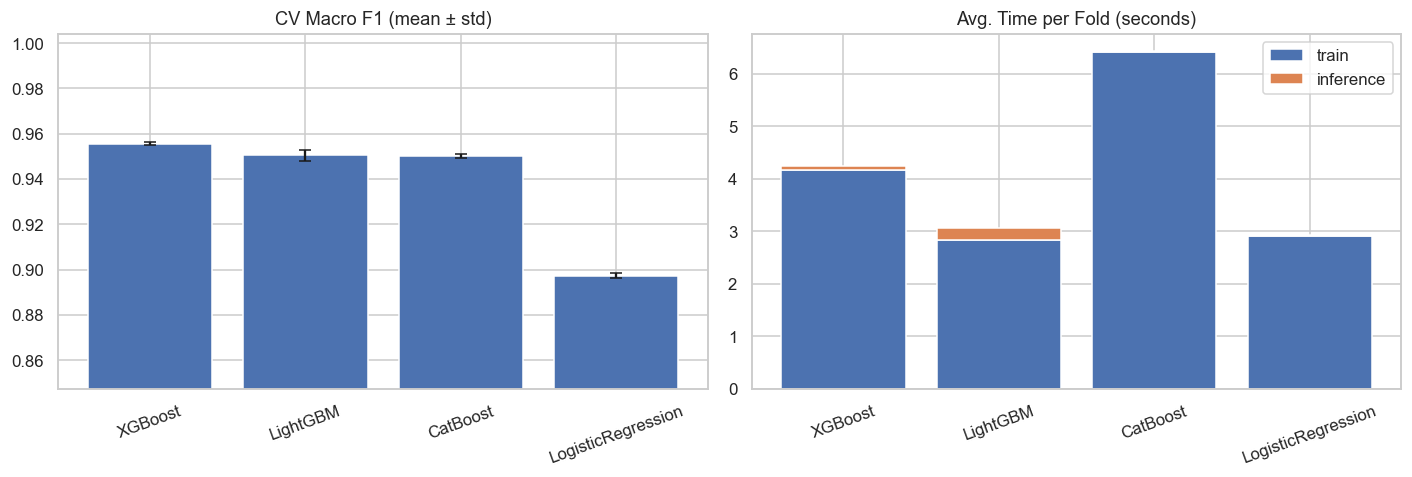

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    results_df["model_name"],
    results_df["cv_f1_macro_mean"],
    yerr=results_df["cv_f1_macro_std"],
    capsize=4,
)
axes[0].set_title("CV Macro F1 (mean ± std)")
axes[0].set_ylim(bottom=max(0, results_df["cv_f1_macro_mean"].min() - 0.05))

axes[1].bar(results_df["model_name"], results_df["avg_train_time_sec"], label="train")
axes[1].bar(
    results_df["model_name"],
    results_df["avg_inference_time_sec"],
    bottom=results_df["avg_train_time_sec"],
    label="inference",
)
axes[1].set_title("Avg. Time per Fold (seconds)")
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [9]:
best_model_name = results_df.iloc[0]["model_name"]
print(f"Best baseline by CV macro F1: {best_model_name}")

Best baseline by CV macro F1: XGBoost


6. Error Analysis - for the model XGBoost as its an best baseline


              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98    377480
         QSO       0.97      0.96      0.96    117143
        STAR       0.93      0.92      0.93     82724

    accuracy                           0.97    577347
   macro avg       0.96      0.95      0.96    577347
weighted avg       0.97      0.97      0.97    577347



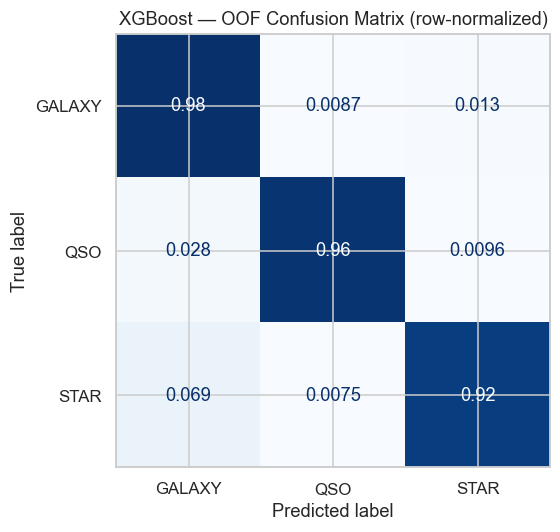

In [10]:
best_oof_predictions = all_results[best_model_name]["oof_predictions"]

print(classification_report(y, best_oof_predictions, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y,
    best_oof_predictions,
    display_labels=CLASS_NAMES,
    normalize="true",
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title(f"{best_model_name} — OOF Confusion Matrix (row-normalized)")
plt.tight_layout()
plt.show()

7. results -> and saving them in the result folder 

In [11]:
results_output_path = RESULTS_DIR / "baseline_results.csv"
results_df.to_csv(results_output_path, index=False)
print(f"Saved comparison table to {results_output_path}")

oof_output_path = DATA_DIR / "processed" / "oof_baseline_predictions.npz"
np.savez(
    oof_output_path,
    y_true=y,
    **{
        f"{name}_oof_proba": result["oof_probabilities"]
        for name, result in all_results.items()
    },
)
print(f"Saved OOF probabilities for all {len(all_results)} models to {oof_output_path}")

Saved comparison table to ..\results\baseline_results.csv
Saved OOF probabilities for all 4 models to ..\data\processed\oof_baseline_predictions.npz
